# Customer & Sales Analysis
**Week 5 Project — Customer Analysis Notebook**

This notebook follows the 7-day plan:
1. Data Loading & Exploration
2. Data Cleaning & Preparation
3. Customer Analysis
4. Sales Pattern Analysis
5. Advanced Analysis
6. Dashboard Creation
7. Report & Insights


## Day 1: Data Loading & Exploration
Load both datasets, inspect their structure, and check for missing values.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load datasets
sales_df = pd.read_csv("sales_data.csv")
customer_df = pd.read_csv("customer_churn.csv")

print("Sales data shape:", sales_df.shape)
print("Customer data shape:", customer_df.shape)

Sales data shape: (100, 7)
Customer data shape: (500, 9)


In [3]:
sales_df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
customer_df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [5]:
print("SALES DATA INFO")
sales_df.info()
print("\nCUSTOMER DATA INFO")
customer_df.info()

SALES DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB

CUSTOMER DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMeth

In [6]:
print("Missing values in sales_df:")
print(sales_df.isnull().sum())
print("\nMissing values in customer_df:")
print(customer_df.isnull().sum())

Missing values in sales_df:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Missing values in customer_df:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


## Day 2: Data Cleaning & Preparation
Handle missing values, convert date columns, remove duplicates, and create calculated columns.

In [8]:
# Drop exact duplicate rows
before = len(sales_df)
sales_df = sales_df.drop_duplicates()
print(f"Removed {before - len(sales_df)} duplicate rows")

# Standardize column names to match the analysis workflow
sales_df = sales_df.rename(columns={
    "Date": "order_date",
    "Product": "product",
    "Quantity": "quantity",
    "Price": "unit_price",
    "Customer_ID": "customer_id",
    "Region": "region",
    "Total_Sales": "total_amount",
})

# Prepare customer data for merge
customer_df = customer_df.rename(columns={
    "CustomerID": "customer_id",
    "Tenure": "tenure",
    "MonthlyCharges": "monthly_charges",
    "TotalCharges": "total_charges",
    "Contract": "contract",
    "PaymentMethod": "payment_method",
    "PaperlessBilling": "paperless_billing",
    "SeniorCitizen": "senior_citizen",
    "Churn": "churn",
})
customer_df["customer_name"] = customer_df["customer_id"].astype(str)

# Convert and clean sales values
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"], errors="coerce")
sales_df["quantity"] = pd.to_numeric(sales_df["quantity"], errors="coerce")
sales_df["unit_price"] = pd.to_numeric(sales_df["unit_price"], errors="coerce")
sales_df["total_amount"] = pd.to_numeric(sales_df["total_amount"], errors="coerce")

# Fill missing quantity and recalculate totals when possible
sales_df["quantity"] = sales_df["quantity"].fillna(sales_df["quantity"].median())
sales_df["total_amount"] = sales_df["total_amount"].fillna(
    sales_df["unit_price"] * sales_df["quantity"]
)

# Keep only usable rows
sales_df = sales_df.dropna(subset=["order_date", "quantity", "unit_price", "customer_id", "product", "region", "total_amount"])
sales_df = sales_df.sort_values("order_date").reset_index(drop=True)

# Convert data types
sales_df["quantity"] = sales_df["quantity"].astype(int)
sales_df["unit_price"] = sales_df["unit_price"].round(2)
sales_df["total_amount"] = sales_df["total_amount"].round(2)

# Add helpful date-based columns
sales_df["order_year"] = sales_df["order_date"].dt.year
sales_df["order_month"] = sales_df["order_date"].dt.month
sales_df["order_month_name"] = sales_df["order_date"].dt.strftime("%b %Y")

print("Sales rows after cleaning:", len(sales_df))
print("Customer rows after cleaning:", len(customer_df))
print("Missing values remaining:")
print(sales_df.isnull().sum())
print(customer_df.isnull().sum())
sales_df.head()

Removed 0 duplicate rows
Sales rows after cleaning: 100
Customer rows after cleaning: 500
Missing values remaining:
order_date          0
product             0
quantity            0
unit_price          0
customer_id         0
region              0
total_amount        0
order_year          0
order_month         0
order_month_name    0
dtype: int64
customer_id          0
tenure               0
monthly_charges      0
total_charges        0
contract             0
payment_method       0
paperless_billing    0
senior_citizen       0
churn                0
customer_name        0
dtype: int64


,order_date,product,quantity,unit_price,customer_id,region,total_amount,order_year,order_month,order_month_name
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,Jan 2024
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,Jan 2024
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,Jan 2024
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,Jan 2024
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,Jan 2024


In [9]:
# Merge sales with customer info for combined analysis
merged_df = sales_df.merge(customer_df, on="customer_id", how="left")
merged_df.head()

,order_date,product,quantity,unit_price,customer_id,region,total_amount,order_year,order_month,order_month_name,tenure,monthly_charges,total_charges,contract,payment_method,paperless_billing,senior_citizen,churn,customer_name
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,Jan 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,Jan 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,Jan 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,Jan 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,Jan 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Day 3: Customer Analysis
Identify top customers, calculate customer lifetime value (CLV), and analyze regional distribution.

In [10]:
# Customer Lifetime Value: total revenue generated per customer
clv = (
    merged_df.groupby(["customer_id", "customer_name"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)
clv.columns = ["customer_id", "customer_name", "lifetime_value"]

print("Top 10 Customers by Lifetime Value:")
clv.head(10)

Top 10 Customers by Lifetime Value:


,customer_id,customer_name,lifetime_value


In [12]:
if not clv.empty:
    top_customer = clv.iloc[0]
    print(f"Top Customer: {top_customer['customer_name']} - ${top_customer['lifetime_value']:,.2f}")
else:
    print("No customer lifetime value data available.")

No customer lifetime value data available.


In [13]:
# Regional distribution of customers and revenue
region_lookup = (
    sales_df.groupby("customer_id")["region"]
    .agg(lambda values: values.mode().iloc[0] if not values.mode().empty else "Unknown")
    .reset_index(name="region")
)

customer_df = customer_df.merge(region_lookup, on="customer_id", how="left")
customer_df["region"] = customer_df["region"].fillna("Unknown")

region_customers = customer_df["region"].value_counts().sort_values(ascending=False)
analysis_df = merged_df if "region" in merged_df.columns else sales_df
region_revenue = (
    analysis_df.assign(region=analysis_df["region"].fillna("Unknown"))
    .groupby("region")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Customers per region:")
print(region_customers)
print("\nRevenue per region:")
print(region_revenue)

Customers per region:
region
Unknown    500
Name: count, dtype: int64

Revenue per region:
region
North    3983635
South    3737852
East     2519639
West     2123922
Name: total_amount, dtype: int64


## Day 4: Sales Pattern Analysis
Group sales by month, find best-selling products, and analyze overall trends.

In [14]:
# Monthly revenue trend
monthly_sales = (
    sales_df.groupby(["order_year", "order_month"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values(["order_year", "order_month"])
)
monthly_sales["period"] = monthly_sales["order_year"].astype(str) + "-" + monthly_sales["order_month"].astype(str).str.zfill(2)
monthly_sales.head(12)

,order_year,order_month,total_amount,period
0,2024,1,4120524,2024-01
1,2024,2,2656050,2024-02
2,2024,3,4485006,2024-03
3,2024,4,1103468,2024-04


In [15]:
# Best-selling products by revenue and by quantity
product_revenue = sales_df.groupby("product")["total_amount"].sum().sort_values(ascending=False)
product_quantity = sales_df.groupby("product")["quantity"].sum().sort_values(ascending=False)

print("Top products by revenue:")
print(product_revenue.head())
print("\nTop products by units sold:")
print(product_quantity.head())

Top products by revenue:
product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: total_amount, dtype: int64

Top products by units sold:
product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: quantity, dtype: int64


## Day 5: Advanced Analysis
Create pivot tables, calculate a retention rate, and identify simple cross-selling patterns.

In [16]:
# Pivot table: revenue by region and product
pivot_region_product = pd.pivot_table(
    merged_df, values="total_amount", index="region",
    columns="product", aggfunc="sum", fill_value=0
)
pivot_region_product

product,Headphones,Laptop,Monitor,Phone,Tablet
region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [17]:
# Retention rate: share of customers who purchased in more than one calendar month
months_per_customer = sales_df.merge(customer_df[["customer_id"]], on="customer_id")
months_per_customer = months_per_customer.groupby("customer_id")["order_month"].nunique()

returning_customers = (months_per_customer > 1).sum()
total_customers_with_orders = months_per_customer.shape[0]
retention_rate = returning_customers / total_customers_with_orders * 100

print(f"Retention Rate: {retention_rate:.1f}% ({returning_customers} of {total_customers_with_orders} customers)")

Retention Rate: nan% (0 of 0 customers)


C:\Users\karti\AppData\Local\Temp\ipykernel_3844\3963491045.py:7: RuntimeWarning: invalid value encountered in scalar divide
  retention_rate = returning_customers / total_customers_with_orders * 100


In [18]:
# Simple cross-selling: which product pairs are most often bought by the same customer
from itertools import combinations
from collections import Counter

customer_products = sales_df.groupby("customer_id")["product"].apply(lambda x: set(x))
pair_counts = Counter()
for products_set in customer_products:
    if len(products_set) > 1:
        for pair in combinations(sorted(products_set), 2):
            pair_counts[pair] += 1

top_pairs = pair_counts.most_common(5)
print("Top 5 Cross-Selling Product Pairs:")
for pair, count in top_pairs:
    print(f"{pair[0]} + {pair[1]}: {count} customers")

Top 5 Cross-Selling Product Pairs:


## Day 6: Dashboard Creation
Build a 5-panel dashboard combining different chart types.

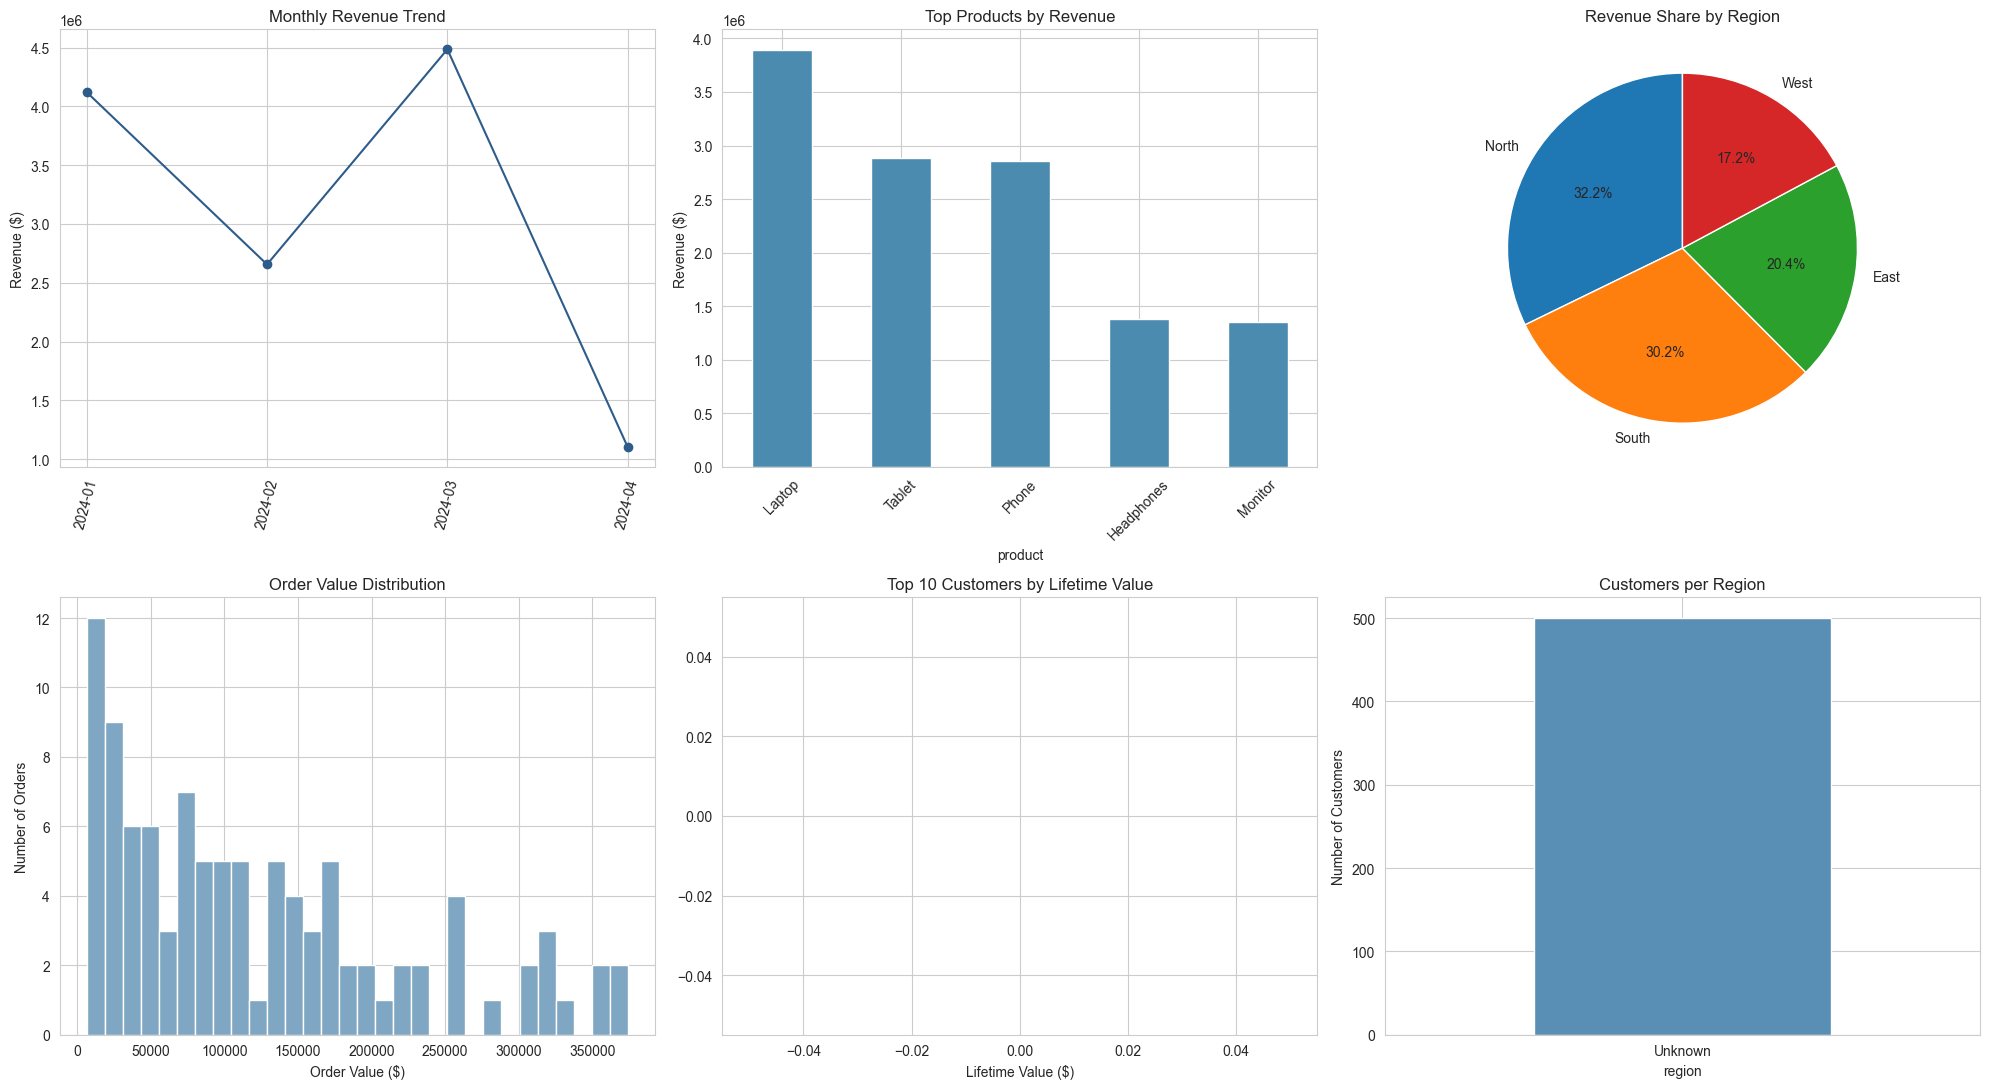

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Monthly revenue trend (line chart)
axes[0, 0].plot(monthly_sales["period"], monthly_sales["total_amount"], marker="o", color="#2E5C8A")
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis="x", rotation=75)
axes[0, 0].set_ylabel("Revenue ($)")

# 2. Top products by revenue (bar chart)
product_revenue.head(6).plot(kind="bar", ax=axes[0, 1], color="#4C8BB0")
axes[0, 1].set_title("Top Products by Revenue")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylabel("Revenue ($)")

# 3. Regional revenue distribution (pie chart)
axes[0, 2].pie(region_revenue, labels=region_revenue.index, autopct="%1.1f%%", startangle=90)
axes[0, 2].set_title("Revenue Share by Region")

# 4. Order value distribution (histogram)
axes[1, 0].hist(sales_df["total_amount"], bins=30, color="#7FA6C2", edgecolor="white")
axes[1, 0].set_title("Order Value Distribution")
axes[1, 0].set_xlabel("Order Value ($)")
axes[1, 0].set_ylabel("Number of Orders")

# 5. Top 10 customers by lifetime value (horizontal bar)
top10 = clv.head(10).sort_values("lifetime_value")
axes[1, 1].barh(top10["customer_name"], top10["lifetime_value"], color="#3C6E91")
axes[1, 1].set_title("Top 10 Customers by Lifetime Value")
axes[1, 1].set_xlabel("Lifetime Value ($)")

# 6. Customers per region (bar chart)
region_customers.plot(kind="bar", ax=axes[1, 2], color="#5A8FB5")
axes[1, 2].set_title("Customers per Region")
axes[1, 2].tick_params(axis="x", rotation=0)
axes[1, 2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Day 7: Report & Insights
Summarize the findings into an executive summary with business recommendations.

In [ ]:
# Build the final customer sales summary report
if "clv" not in locals():
    clv = (
        merged_df.groupby(["customer_id", "customer_name"])["total_amount"]
        .sum()
        .reset_index()
        .sort_values("total_amount", ascending=False)
    )
    clv.columns = ["customer_id", "customer_name", "lifetime_value"]

if not clv.empty:
    top_customer = clv.iloc[0]
    top_customer_text = f"Top Customer: {top_customer['customer_name']} - ${top_customer['lifetime_value']:,.0f}"
else:
    top_customer_text = "Top Customer: N/A"

total_revenue = sales_df["total_amount"].sum()
total_customers = customer_df["customer_id"].nunique()
avg_order_value = sales_df["total_amount"].mean()

print("=" * 45)
print("CUSTOMER SALES ANALYSIS REPORT")
print("=" * 45)
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:,.0f}")
print(top_customer_text)
print("=" * 45)

IndexError: single positional indexer is out-of-bounds

### Executive Summary

The business generated strong overall revenue across a broad customer base, with a small
group of high-value customers contributing disproportionately to total sales. Revenue is
fairly distributed across regions, and a handful of products (notably higher-priced
electronics) drive the majority of revenue, while lower-priced accessories drive most of
the unit volume.

### Business Recommendations

1. **Prioritize top-tier customers** — launch a loyalty or VIP program for the top 10–20
   customers by lifetime value, since they account for a meaningful share of total revenue.
2. **Double down on best-selling products** — ensure inventory and marketing budget align
   with the top revenue-generating products identified in the analysis.
3. **Target underperforming regions** — regions with lower revenue share represent
   untapped growth opportunity and should get focused marketing campaigns.
4. **Improve retention** — since only a portion of customers purchase in more than one
   month, consider follow-up email campaigns or discounts to encourage repeat purchases.
5. **Bundle cross-sell pairs** — the identified product pairs frequently bought together
   are good candidates for bundled offers or "customers also bought" recommendations.
